In [30]:


import pandas as pd
import matplotlib.pyplot as plt
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path
import sys
from data_registry import datasets
from scipy.ndimage import uniform_filter1d
# os.getcwd()
# os.chdir(r"C:\Users\ryanc\repo\Time-Series-Analysis-Project")
    

In [3]:
cwd = Path.cwd()
cwd

WindowsPath('c:/Users/floydry/repos/Time-Series-Analysis-Project/homework')

# Plot and Exploratory Analysis

*Read data*

In [22]:
cwd.parent

WindowsPath('c:/Users/floydry/repos/Time-Series-Analysis-Project')

In [25]:

snow_data = pd.read_csv('BogusSnowDaily.csv')
snow_data.columns = (['Date', 'Depth'])
snow_data['Date'] = pd.to_datetime(snow_data['Date'])

snow_daily = pd.Series(snow_data['Depth'].values, index=snow_data['Date'])

snow_monthly = snow_daily.resample('ME').mean()
snow_monthly.head()
snow_daily.head()


Date
1999-09-23    0
1999-09-24    0
1999-09-25    0
1999-09-26    0
1999-09-27    0
dtype: int64

In [27]:
from plots.ts_plot import ts_plot
from plots.residual_plot import residual_plot

C:\Users\floydry\AppData\Local\Temp\ipykernel_36408\2972221242.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


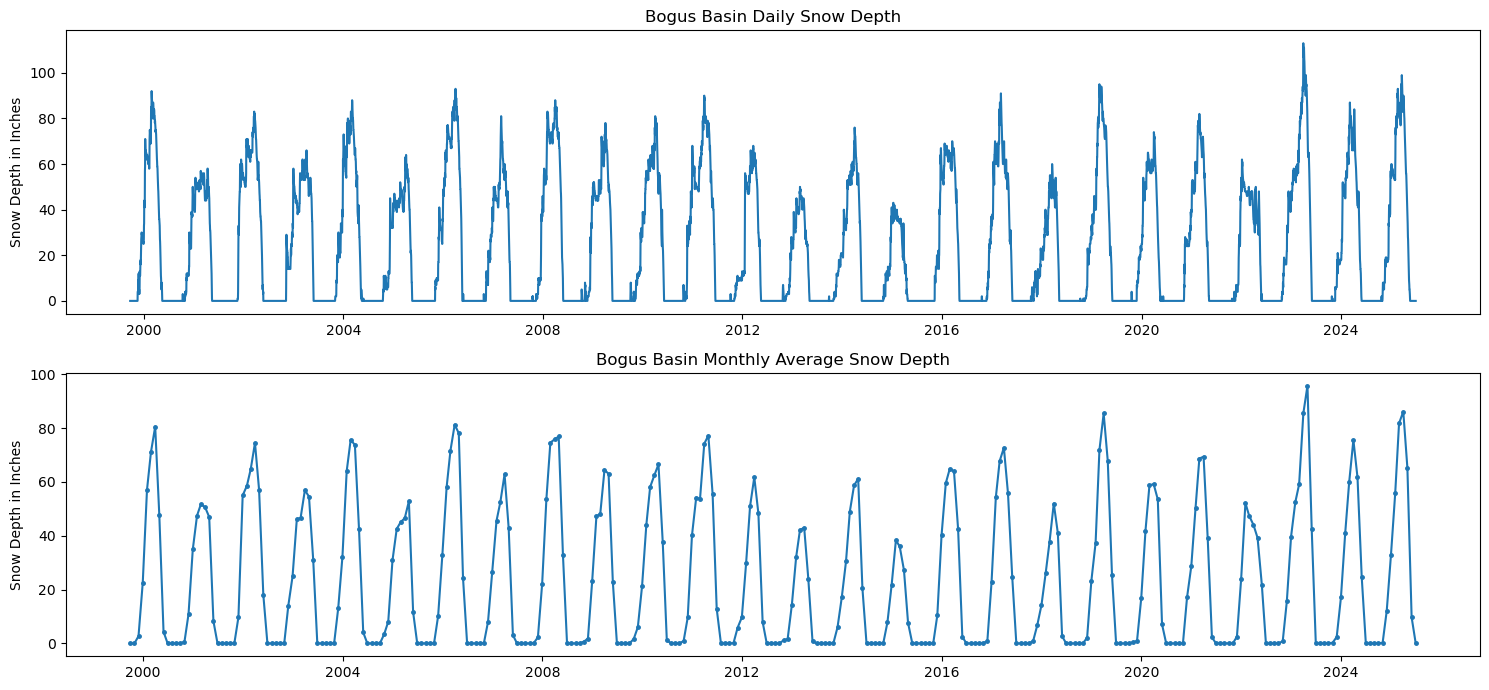

In [28]:
fig, axs = plt.subplots(2,1, figsize=(15,7))
axs[0].plot(snow_daily)
axs[0].set_title('Bogus Basin Daily Snow Depth')
axs[0].set_ylabel("Snow Depth in Inches")

axs[1].plot(snow_monthly, marker = '.', markersize = 5  )
axs[1].set_title('Bogus Basin Monthly Average Snow Depth')
axs[1].set_ylabel("Snow Depth in Inches")
fig.tight_layout()
fig.show()

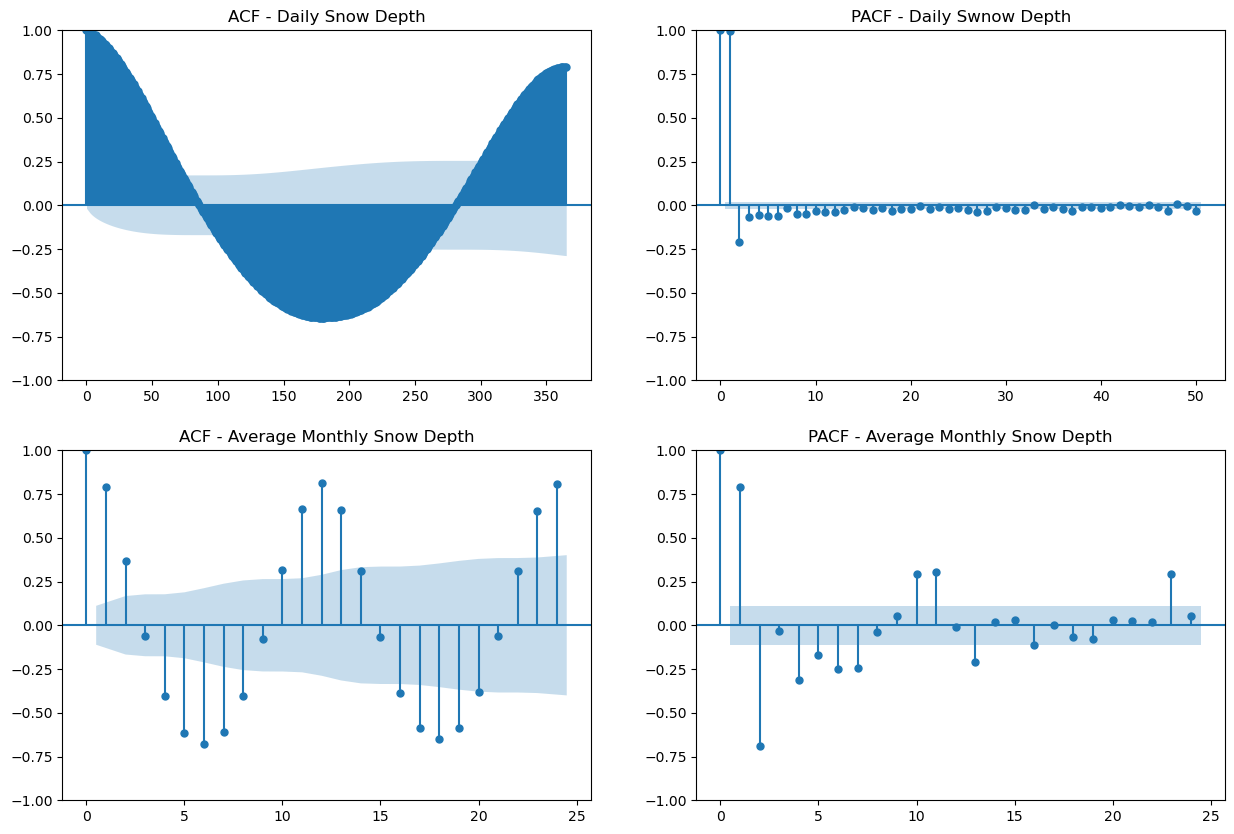

In [29]:
fig, axs = plt.subplots(2,2, figsize = (15,10))
plot_acf(snow_daily, lags = 365, ax = axs[0,0], title = 'ACF - Daily Snow Depth');
plot_pacf(snow_daily, lags = 50, ax = axs[0,1], title = "PACF - Daily Swnow Depth");

plot_acf(snow_monthly, lags = 24, ax = axs[1,0], title  = "ACF - Average Monthly Snow Depth");
plot_pacf(snow_monthly, lags = 24, ax = axs[1,1], title = 'PACF - Average Monthly Snow Depth');

# Moving Average with Seasonal Anova


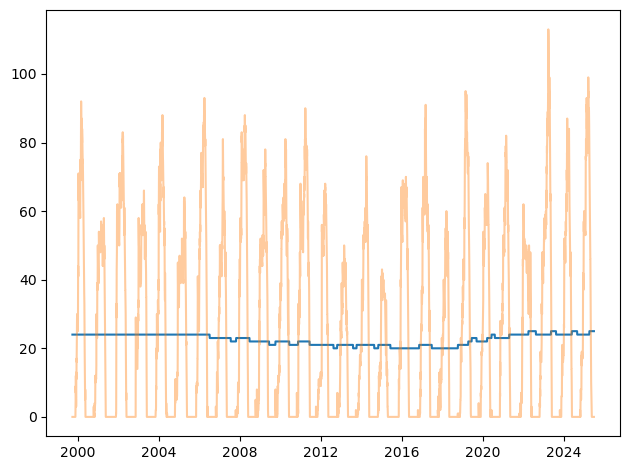

In [60]:
mavModel = uniform_filter1d(snow_daily, size=len(snow_daily)//2)
mavModel
mav_data = pd.Series(mavModel, index=snow_daily.index)
plt.plot(mav_data)
plt.plot(snow_daily, alpha =.4)
plt.tight_layout()

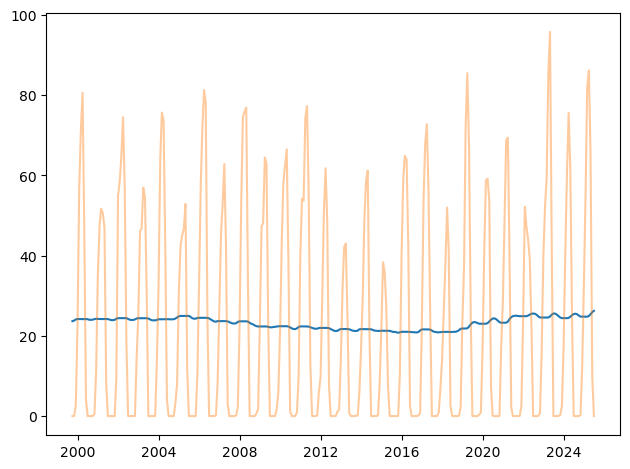

In [55]:
monthly_mavModel = uniform_filter1d(snow_monthly, size=len(snow_monthly)//2)

monthly_mav_data = pd.Series(monthly_mavModel, index=snow_monthly.index)
plt.plot(monthly_mav_data)
plt.plot(snow_monthly, alpha =.4)
plt.tight_layout()

In [59]:
len(snow_monthly)

310